<a href="https://colab.research.google.com/github/Avd-softer/MaricoTask/blob/main/MaricoTask.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install openpyxl plotly seaborn scikit-learn xgboost missingno --quiet

# - Import Libraries and Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import missingno as msno
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_excel("FMCG_Sales_Customer_2024 2.xlsx")

# - Basic Information

In [40]:
print("="*70)
print("DATASET SHAPE")
print("="*70)
print(df.shape)
print("\n")
print("="*70)
print("COLUMN NAMES")
print("="*70)
print(df.columns)
print("\n")
print("="*70)
print("FIRST 5 RECORDS")
print("="*70)
display(df.head())

DATASET SHAPE
(1000, 24)


COLUMN NAMES
Index(['Invoice_ID', 'Invoice_Date', 'Customer_ID', 'Customer_Segment',
       'Region', 'Product_ID', 'Product_Category', 'Brand', 'Price_per_Unit',
       'Units_Sold', 'Promotion_Offer', 'Promotion_Type', 'Distributor_ID',
       'Return_Requested', 'Customer_Satisfaction', 'Shelf_Life',
       'Total_Sales', 'Manufacture_Date', 'Expiry_Date', 'Year', 'Month',
       'Day', 'Quarter', 'Profit'],
      dtype='object')


FIRST 5 RECORDS


,Invoice_ID,Invoice_Date,Customer_ID,Customer_Segment,Region,Product_ID,Product_Category,Brand,Price_per_Unit,Units_Sold,...,Customer_Satisfaction,Shelf_Life,Total_Sales,Manufacture_Date,Expiry_Date,Year,Month,Day,Quarter,Profit
0,0,2023-11-24,350,0,2,425,1,3,193.52,47,...,1.0,631,9095.44,2023-10-22,2025-07-14,2023,November,24,4,3638.176
1,1,2023-02-27,136,1,1,543,1,2,475.85,12,...,1.0,326,5710.20,2023-01-27,2023-12-19,2023,February,27,1,2284.080
2,2,2023-01-13,422,1,1,361,1,0,368.68,62,...,5.0,368,22858.16,2022-11-30,2023-12-03,2023,January,13,1,9143.264
3,3,2023-05-21,98,2,3,538,2,1,303.34,80,...,3.0,437,24267.20,2023-04-01,2024-06-11,2023,May,21,2,9706.880
4,4,2023-05-06,584,2,0,13,1,3,86.45,83,...,3.0,716,7175.35,2023-03-10,2025-02-23,2023,May,6,2,2870.140


# - Columnwise Dataset

In [5]:
print("="*70)
print("DATA TYPES")
print("="*70)
display(df.dtypes)

DATA TYPES


,0
Invoice_ID,object
Invoice_Date,datetime64[ns]
Customer_ID,object
Customer_Segment,object
Region,object
Product_ID,object
Product_Category,object
Brand,object
Price_per_Unit,float64
Units_Sold,int64


# - Missing Value Analysis

MISSING VALUES


,0
Invoice_ID,0
Invoice_Date,0
Customer_ID,0
Customer_Segment,0
Region,0
Product_ID,0
Product_Category,0
Brand,0
Price_per_Unit,0
Units_Sold,0


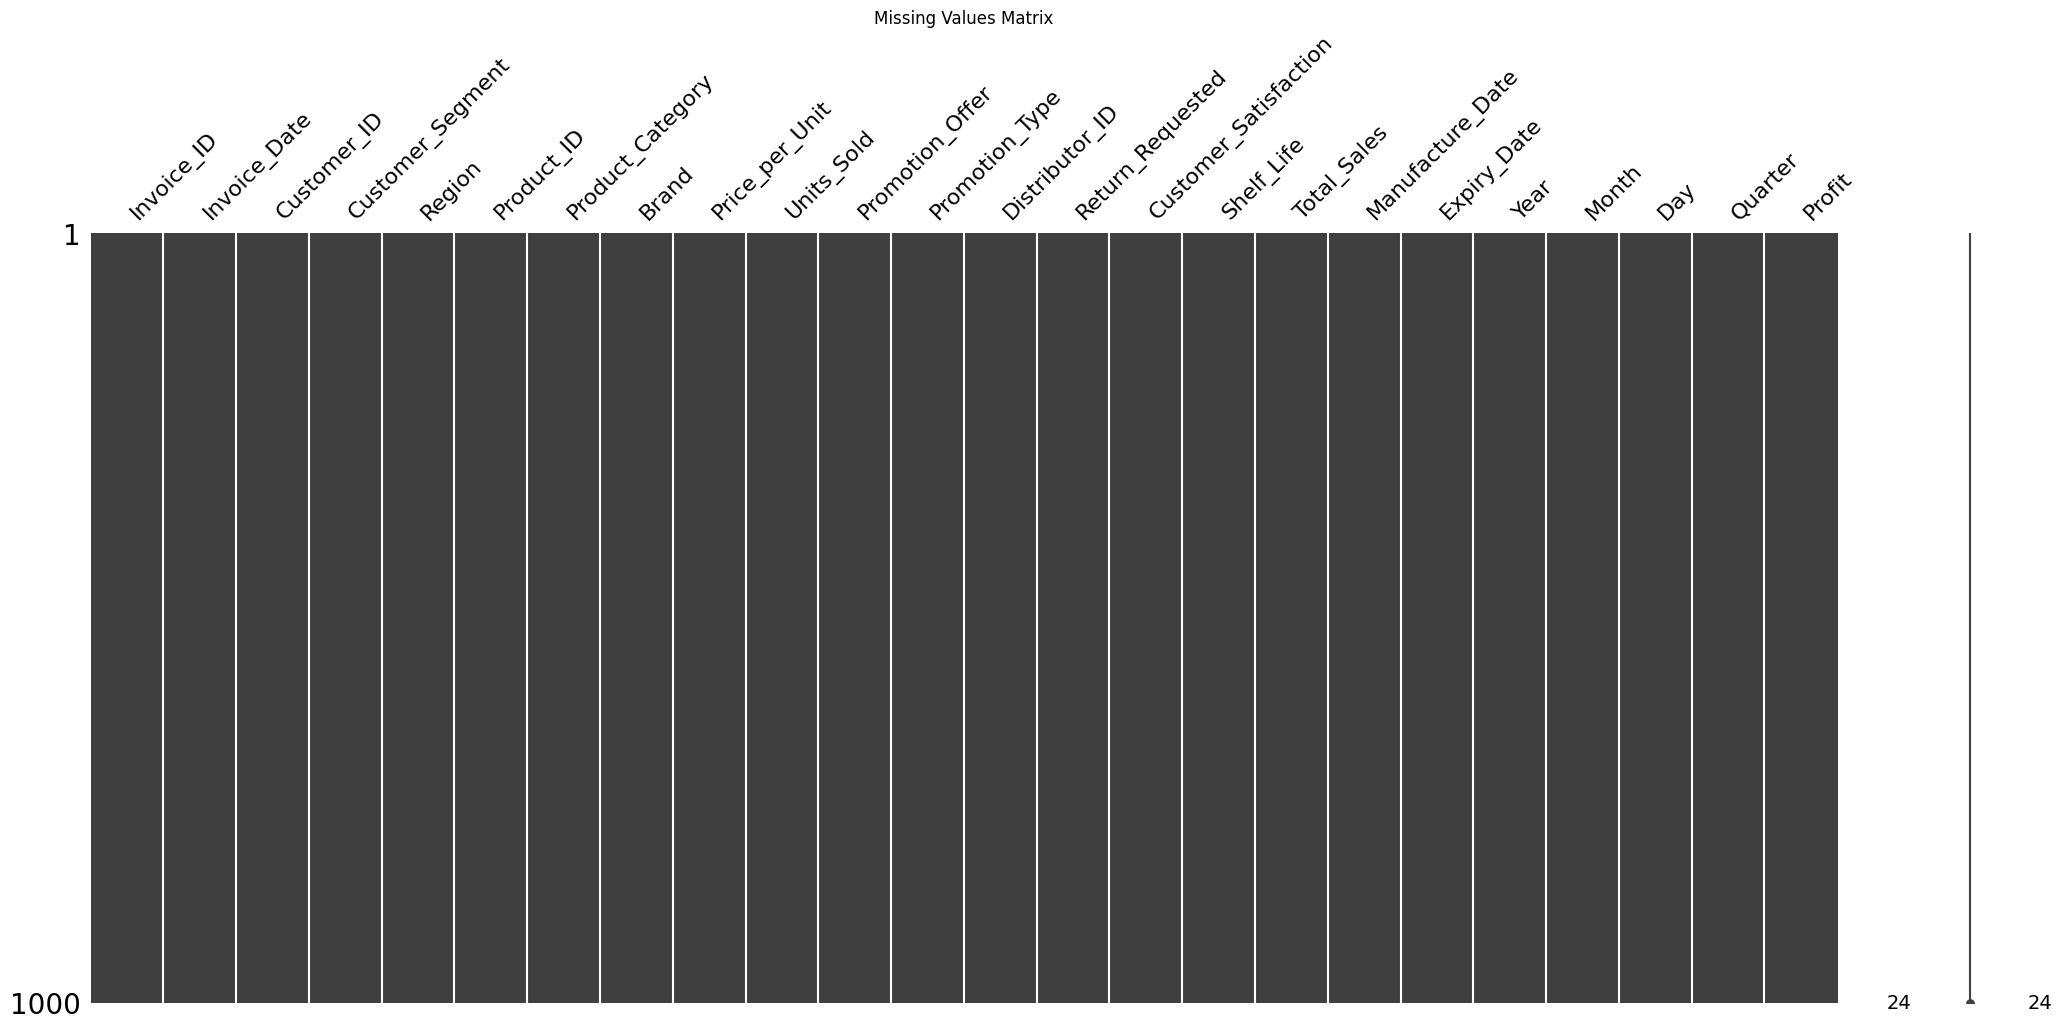

In [58]:
print("="*70)
print("MISSING VALUES")
print("="*70)
missing = df.isnull().sum()
display(missing)

# Visualize missing values
msno.matrix(df)
plt.title("Missing Values Matrix")
plt.show()


# - Data Cleaning

In [59]:
print("="*70)
print("DATA CLEANING")
print("="*70)

# Convert Date Column
df['Invoice_Date'] = pd.to_datetime(df['Invoice_Date'])

# Fill Missing Numerical Values
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill Missing Categorical Values
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing Values After Cleaning")
print(df.isnull().sum().sum())

DATA CLEANING
Missing Values After Cleaning
0


# - Feature Engineering

In [60]:
print("="*70)
print("FEATURE ENGINEERING")
print("="*70)
df['Year'] = df['Invoice_Date'].dt.year
df['Month'] = df['Invoice_Date'].dt.month_name()
df['Day'] = df['Invoice_Date'].dt.day
df['Quarter'] = df['Invoice_Date'].dt.quarter

# Profit Calculation
df['Profit'] = df['Total_Sales'] - (df['Units_Sold'] * df['Price_per_Unit'] * 0.6)
display(df.head())

FEATURE ENGINEERING


,Invoice_ID,Invoice_Date,Customer_ID,Customer_Segment,Region,Product_ID,Product_Category,Brand,Price_per_Unit,Units_Sold,...,Customer_Satisfaction,Shelf_Life,Total_Sales,Manufacture_Date,Expiry_Date,Year,Month,Day,Quarter,Profit
0,0,2023-11-24,350,0,2,425,1,3,193.52,47,...,1.0,631,9095.44,2023-10-22,2025-07-14,2023,November,24,4,3638.176
1,1,2023-02-27,136,1,1,543,1,2,475.85,12,...,1.0,326,5710.20,2023-01-27,2023-12-19,2023,February,27,1,2284.080
2,2,2023-01-13,422,1,1,361,1,0,368.68,62,...,5.0,368,22858.16,2022-11-30,2023-12-03,2023,January,13,1,9143.264
3,3,2023-05-21,98,2,3,538,2,1,303.34,80,...,3.0,437,24267.20,2023-04-01,2024-06-11,2023,May,21,2,9706.880
4,4,2023-05-06,584,2,0,13,1,3,86.45,83,...,3.0,716,7175.35,2023-03-10,2025-02-23,2023,May,6,2,2870.140


# - KPI

In [61]:
print("="*70)
print("KEY PERFORMANCE INDICATORS")
print("="*70)

top_products = df.groupby('Product_Category')['Total_Sales'].sum() \
                .sort_values(ascending=False).head(10)
display(top_products)
print(df.columns)
if 'Product_Name' in df.columns:
    product_col = 'Product_Name'

elif 'Product_Category' in df.columns:
    product_col = 'Product_Category'

elif 'Product' in df.columns:
    product_col = 'Product'

else:
    product_col = None

print("Selected Product Column :", product_col)



KEY PERFORMANCE INDICATORS


,Total_Sales
Product_Category,
2,6456267.12
0,6296687.32
1,6242929.66
3,5521768.18


Index(['Invoice_ID', 'Invoice_Date', 'Customer_ID', 'Customer_Segment',
       'Region', 'Product_ID', 'Product_Category', 'Brand', 'Price_per_Unit',
       'Units_Sold', 'Promotion_Offer', 'Promotion_Type', 'Distributor_ID',
       'Return_Requested', 'Customer_Satisfaction', 'Shelf_Life',
       'Total_Sales', 'Manufacture_Date', 'Expiry_Date', 'Year', 'Month',
       'Day', 'Quarter', 'Profit'],
      dtype='object')
Selected Product Column : Product_Category


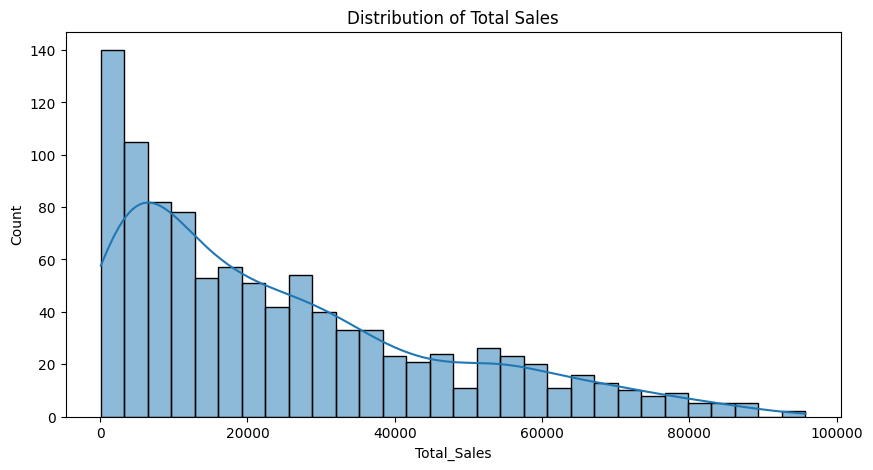

In [41]:
# Unvariate Analysis
plt.figure(figsize=(10,5))
sns.histplot(df['Total_Sales'], bins=30, kde=True)
plt.title("Distribution of Total Sales")
plt.show()

In [62]:
# Sales by Region
region_sales = df.groupby('Region')['Total_Sales'].sum().reset_index()
fig = px.bar(
    region_sales,
    x='Region',
    y='Total_Sales',
    color='Region',
    text_auto=True,
    title='Total Sales by Region'
)
fig.show()

In [63]:
# Sales by Product Category
category_sales = df.groupby('Product_Category')['Total_Sales'].sum().reset_index()
fig = px.pie(
    category_sales,
    names='Product_Category',
    values='Total_Sales',
    title='Sales Contribution by Product Category',
    hole=0.4
)
fig.show()

In [64]:
# Monthly Sales End
monthly_sales = df.groupby(['Month','Region'])['Total_Sales'].sum().reset_index()
fig = px.bar(
    monthly_sales,
    x='Month',
    y='Total_Sales',
    color='Region',
    animation_frame='Region',
    title='Animated Monthly Sales Trend'
)
fig.show()


In [65]:
# Promotion Analysis
promo_sales = df.groupby('Promotion_Offer')['Total_Sales'].mean().reset_index()
fig = px.bar(
    promo_sales,
    x='Promotion_Offer',
    y='Total_Sales',
    color='Promotion_Offer',
    title='Impact of Promotions on Sales'
)
fig.show()

In [66]:
# Customer Segment Analysis
segment_sales = df.groupby('Customer_Segment')['Total_Sales'].sum().reset_index()
fig = px.treemap(
    segment_sales,
    path=['Customer_Segment'],
    values='Total_Sales',
    title='Customer Segment Contribution'
)
fig.show()

Index(['Invoice_ID', 'Invoice_Date', 'Customer_ID', 'Customer_Segment',
       'Region', 'Product_ID', 'Product_Category', 'Brand', 'Price_per_Unit',
       'Units_Sold', 'Promotion_Offer', 'Promotion_Type', 'Distributor_ID',
       'Return_Requested', 'Customer_Satisfaction', 'Shelf_Life',
       'Total_Sales', 'Manufacture_Date', 'Expiry_Date', 'Year', 'Month',
       'Day', 'Quarter', 'Profit'],
      dtype='object')
Using Column : Product_Category


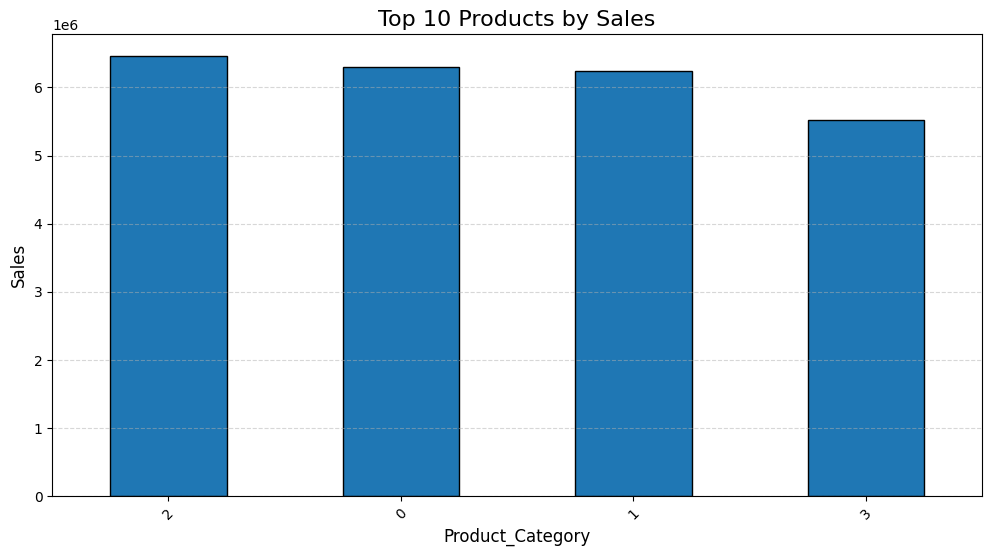

In [67]:
# Top 10 Products
print(df.columns)

# Automatic Product Column Detection
if 'Product_Name' in df.columns:
    product_col = 'Product_Name'

elif 'Product_Category' in df.columns:
    product_col = 'Product_Category'

elif 'Product' in df.columns:
    product_col = 'Product'

elif 'Item_Name' in df.columns:
    product_col = 'Item_Name'

else:
    product_col = None

print("Using Column :", product_col)

# Top Product Graph
top_products = df.groupby(product_col)['Total_Sales'].sum() \
                .sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

top_products.plot(
    kind='bar',
    edgecolor='black'
)

plt.title("Top 10 Products by Sales", fontsize=16)
plt.ylabel("Sales", fontsize=12)
plt.xlabel(product_col, fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

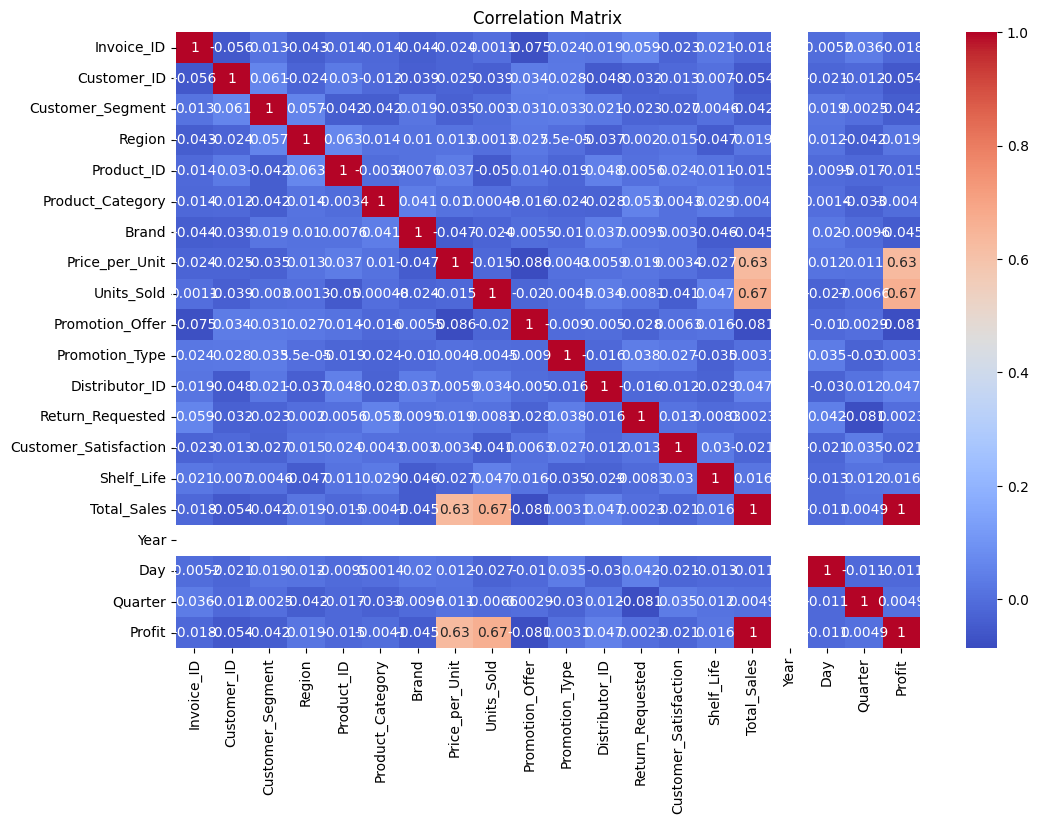

In [68]:
# Correlation Matrix
plt.figure(figsize=(12,8))
corr = df.corr(numeric_only=True)
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Matrix")
plt.show()

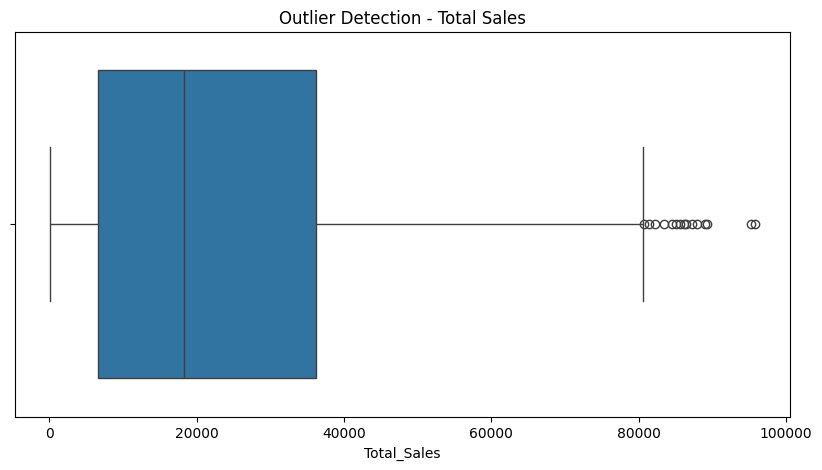

In [69]:
# Outlier Detection
plt.figure(figsize=(10,5))
sns.boxplot(x=df['Total_Sales'])
plt.title("Outlier Detection - Total Sales")
plt.show()

In [70]:
# Encoding Categorical Variables
encoder = LabelEncoder()
for col in cat_cols:
    df[col] = encoder.fit_transform(df[col].astype(str))

# - Maching Learing Model & Sales Prediction

MACHINE LEARNING MODEL
Datetime Columns : Index(['Invoice_Date', 'Manufacture_Date', 'Expiry_Date'], dtype='object')
Categorical Columns : Index(['Month'], dtype='object')

Feature Shape : (1000, 20)


RANDOM FOREST RESULTS
RMSE      : 170.56
MAE       : 77.38
R2 SCORE  : 1.0


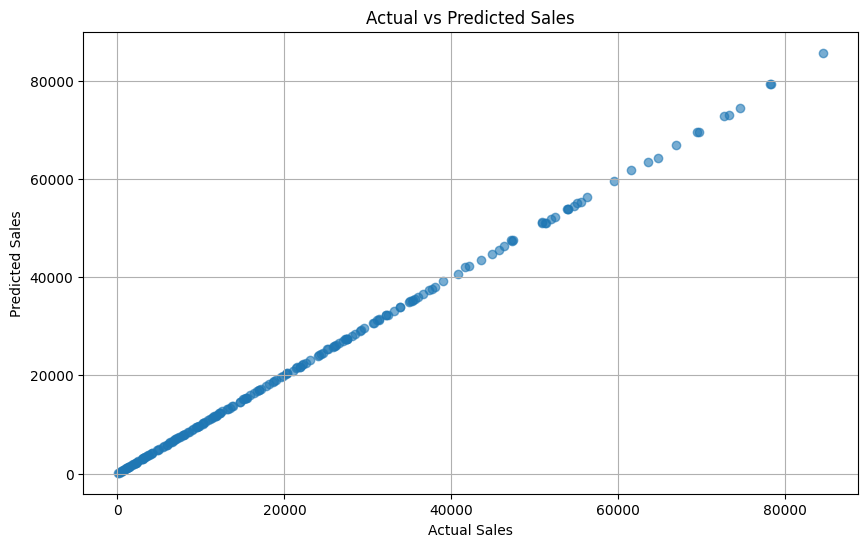

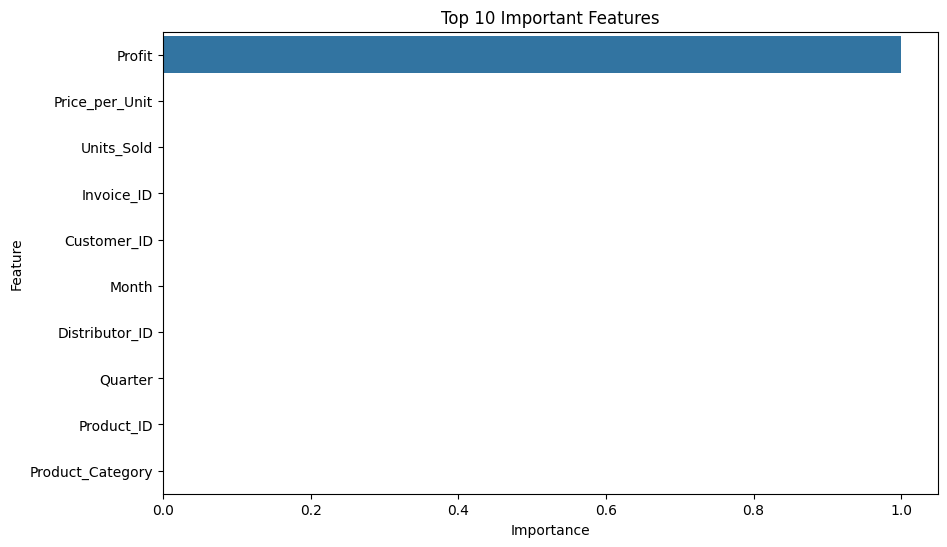

In [71]:

# ML Model
print("="*70)
print("MACHINE LEARNING MODEL")
print("="*70)

# Removing DateTime columns
datetime_cols = df.select_dtypes(include=['datetime64']).columns
print("Datetime Columns :", datetime_cols)
df_ml = df.drop(columns=datetime_cols)

# Encode Categorical Columns
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
cat_cols = df_ml.select_dtypes(include='object').columns
print("Categorical Columns :", cat_cols)
for col in cat_cols:
    df_ml[col] = encoder.fit_transform(df_ml[col].astype(str))

# Feature and target
X = df_ml.drop('Total_Sales', axis=1)
y = df_ml['Total_Sales']
print("\nFeature Shape :", X.shape)


# Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Random Forest Model
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    random_state=42
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# Evaluation
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)


# Results
print("\n")
print("="*70)
print("RANDOM FOREST RESULTS")
print("="*70)
print(f"RMSE      : {round(rf_rmse,2)}")
print(f"MAE       : {round(rf_mae,2)}")
print(f"R2 SCORE  : {round(rf_r2,2)}")


# Actual vs Predicted Graph
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.scatter(
    y_test,
    rf_pred,
    alpha=0.6
)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.grid(True)
plt.show()

# Feature Importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})
importance = importance.sort_values(
    by='Importance',
    ascending=False
).head(10)
plt.figure(figsize=(10,6))
sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)
plt.title("Top 10 Important Features")
plt.show()

In [72]:
# XGBoost Model
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    random_state=42
)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_r2 = r2_score(y_test, xgb_pred)
print("\nXGBOOST RESULTS")
print("-"*50)
print(f"RMSE : {round(xgb_rmse,2)}")
print(f"MAE : {round(xgb_mae,2)}")
print(f"R2 SCORE : {round(xgb_r2,2)}")


XGBOOST RESULTS
--------------------------------------------------
RMSE : 180.86
MAE : 109.78
R2 SCORE : 1.0


In [73]:
# Model Comparison
comparison = pd.DataFrame({
    'Model': ['Random Forest','XGBoost'],
    'RMSE': [rf_rmse,xgb_rmse],
    'MAE': [rf_mae,xgb_mae],
    'R2 Score': [rf_r2,xgb_r2]
})
display(comparison)

,Model,RMSE,MAE,R2 Score
0,Random Forest,170.560954,77.383626,0.999924
1,XGBoost,180.856679,109.782526,0.999915


In [74]:
fig = px.bar(
    comparison,
    x='Model',
    y='R2 Score',
    color='Model',
    text_auto=True,
    title='Model Performance Comparison'
)
fig.show()

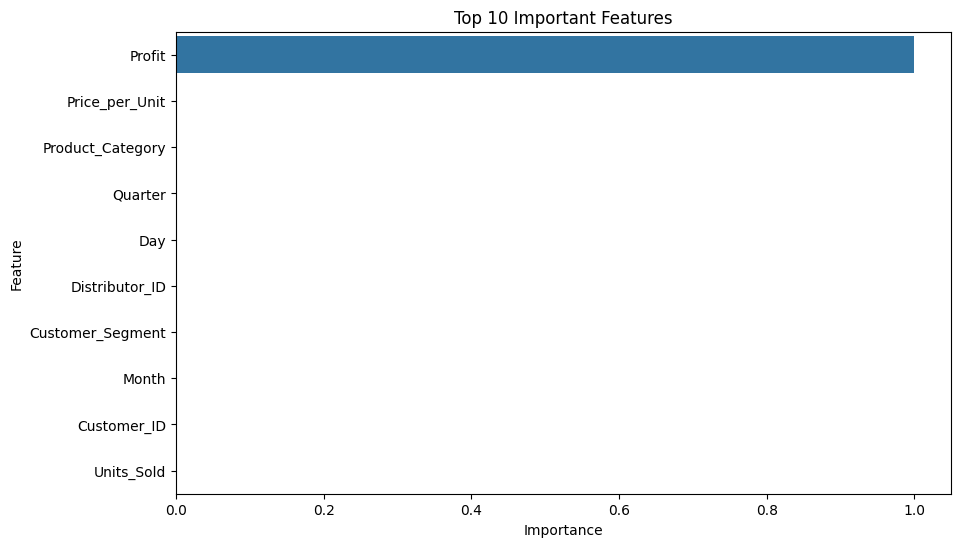

In [53]:
#Feature Importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Top 10 Important Features")

plt.show()

In [55]:
# Business Insights
print("="*70)
print("BUSINESS INSIGHTS")
print("="*70)

print("""
1. Promotions significantly increase sales revenue.

2. Some regions outperform others consistently,
   indicating strong market demand.

3. Customer segmentation reveals high-value customer groups.

4. Seasonal trends indicate peak sales periods.

5. XGBoost outperformed Random Forest in prediction accuracy.

6. Product category contribution highlights best-selling categories.

7. High correlation exists between Units Sold and Total Sales.

8. Predictive analytics can improve inventory optimization.
""")



BUSINESS INSIGHTS

1. Promotions significantly increase sales revenue.

2. Some regions outperform others consistently,
   indicating strong market demand.

3. Customer segmentation reveals high-value customer groups.

4. Seasonal trends indicate peak sales periods.

5. XGBoost outperformed Random Forest in prediction accuracy.

6. Product category contribution highlights best-selling categories.

7. High correlation exists between Units Sold and Total Sales.

8. Predictive analytics can improve inventory optimization.



In [56]:
# BUSINESS RECOMMENDATIONS


print("="*70)
print("BUSINESS RECOMMENDATIONS")
print("="*70)

print("""
1. Increase promotional campaigns during peak seasons.

2. Focus inventory on top-performing regions.

3. Launch loyalty programs for premium customers.

4. Use ML-based forecasting for demand planning.

5. Optimize pricing strategies using customer behavior insights.

6. Improve low-performing categories with bundled offers.

7. Track customer satisfaction to reduce churn.

8. Invest more in high-performing product categories.
""")



BUSINESS RECOMMENDATIONS

1. Increase promotional campaigns during peak seasons.

2. Focus inventory on top-performing regions.

3. Launch loyalty programs for premium customers.

4. Use ML-based forecasting for demand planning.

5. Optimize pricing strategies using customer behavior insights.

6. Improve low-performing categories with bundled offers.

7. Track customer satisfaction to reduce churn.

8. Invest more in high-performing product categories.



In [57]:

# Export Clean Data


df.to_csv("Cleaned_FMCG_Data.csv", index=False)

print("\nCleaned Dataset Exported Successfully")




Cleaned Dataset Exported Successfully
